## This notebook collects all of the code used to run various ROMs for comparison with models
It's not a "run all in one go" notebook like some of the others, but it seemed better to have everything in one place than to have a separate script.
Each cell (details in markdown header) should be self-contained, apart from library imports

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import copy
import os
import warnings
import time

import rom_decadal_lib as rdl

<Figure size 640x480 with 0 Axes>

### Generate linear, quadratic, lookup-table runs off all models and the usual NINO34/equatorial Pacific stuff

In [45]:
kwargs = dict(T_variable = 'nino34',
              h_variable = 'h_eq',
              shape_name = 'pSMILE_qdt', #pseudo-SMILE runs, after detrending quadratically
              inits = None,
              data_labelsel = {'time':slice(None,'2025')}, # Some of these were future at the time but I'm discarding actual future
              run_len = 3600+120+1, # run length
              members=(100,),  # number of ensemble members to generate
              detrend = rdl.declim_detrend_quadratic # how to strip climate change and seasonal cycle from data
             )

for rom_type in ('linear_2D','quadT','lookup_table'):
    kwargs['rom_type'] = rom_type
    for model in ('ACCESS-ESM1-5','CanESM5','CESM1-CAM5','CESM2','IPSL-CM6A-LR','MIROC6','EC-Earth3',):
        kwargs['data_origin'] = model+'_SMILE'
        if model == 'CESM1-CAM5':
            kwargs['data_isel'] = {'time':slice(120,None), # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that
                         'M':np.array([False if x==32 else True for x in range(40)]) # Ensemble member 33 (index 32) has a zero in it that I do _NOT_ need
                        }
        else:
            kwargs['data_isel'] = {'time':slice(120,None)} # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that
        
        t0 = time.time()
        rdl.pseudo_run(**kwargs)
        print(model,rom_type,time.time()-t0)

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/EC-Earth3_SMILE_nino34_h_eq_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


EC-Earth3 linear_2D 2.0663979053497314


/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/EC-Earth3_SMILE_nino34_h_eq_quadT_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


EC-Earth3 quadT 4.657822847366333
EC-Earth3 lookup_table 9.297713994979858


### Generate linear, quadratic, lookup-table runs off all models and the usual NINO34 with WEST PACIFIC


In [2]:
kwargs = dict(T_variable = 'nino34',
              h_variable = 'h_w',
              shape_name = 'pSMILE_qdt', #pseudo-SMILE runs, after detrending quadratically
              inits = None,
              data_labelsel = {'time':slice(None,'2025')}, # Some of these were future at the time but I'm discarding actual future
              run_len = 3600+120+1, # run length
              members=(100,),  # number of ensemble members to generate
              detrend = rdl.declim_detrend_quadratic # how to strip climate change and seasonal cycle from data
             )

for rom_type in ('linear_2D','quadT','lookup_table'):
    kwargs['rom_type'] = rom_type
    for model in ('ACCESS-ESM1-5','CanESM5','CESM1-CAM5','CESM2','IPSL-CM6A-LR','MIROC6'):
        kwargs['data_origin'] = model+'_SMILE'
        if model == 'CESM1-CAM5':
            kwargs['data_isel'] = {'time':slice(120,None), # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that
                         'M':np.array([False if x==32 else True for x in range(40)]) # Ensemble member 33 (index 32) has a zero in it that I do _NOT_ need
                        }
        else:
            kwargs['data_isel'] = {'time':slice(120,None)} # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that
        
        t0 = time.time()
        rdl.pseudo_run(**kwargs)
        print(model,rom_type,time.time()-t0)
        
        #break
        #print(xr.open_dataset('indices/'+kwargs['data_origin']+'_indices.nc',decode_times=False).time)
    #break

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/ACCESS-ESM1-5_SMILE_nino34_h_w_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


ACCESS-ESM1-5 linear_2D 9.267069816589355


/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/CanESM5_SMILE_nino34_h_w_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


CanESM5 linear_2D 2.287715196609497


/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/CESM1-CAM5_SMILE_nino34_h_w_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


...

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invali

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invali

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invali

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invalid value encountered in matmul
  out_xr[:] = np.squeeze(self.A@y0.data + # predictable bit
/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:129: RuntimeWarning: invali

MIROC6 quadT 4.685268878936768
ACCESS-ESM1-5 lookup_table 12.08358883857727
CanESM5 lookup_table 12.274111032485962
CESM1-CAM5 lookup_table 12.243144035339355
CESM2 lookup_table 18.538864850997925
IPSL-CM6A-LR lookup_table 10.82932186126709
MIROC6 lookup_table 12.682739019393921


### Generate linear runs off all models with varied nino and h regions

In [2]:
kwargs = dict(rom_type = 'linear_2D',
              shape_name = 'pSMILE_qdt', #pseudo-SMILE runs, after detrending quadratically
              inits = None,
              data_labelsel = {'time':slice(None,'2025')}, # Some of these were future at the time but I'm discarding actual future
              run_len = 3600+120+1, # run length
              members=(100,),  # number of ensemble members to generate
              detrend = rdl.declim_detrend_quadratic # how to strip climate change and seasonal cycle from data
             )

sigma = {}

for Thvars in (('nino3','h_eq'),('nino34','h_eq'),('nino4','h_eq'),('nino34','h_w')):
    kwargs['T_variable'],kwargs['h_variable'] = Thvars
    for model in ('ACCESS-ESM1-5','CanESM5','CESM1-CAM5','CESM2','IPSL-CM6A-LR','MIROC6'):
        kwargs['data_origin'] = model+'_SMILE'
        if model == 'CESM1-CAM5':
            kwargs['data_isel'] = {'time':slice(120,None), # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that
                         'M':np.array([False if x==32 else True for x in range(40)]) # Ensemble member 33 (index 32) has a zero in it that I do _NOT_ need
                        }
        else:
            kwargs['data_isel'] = {'time':slice(120,None)} # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that

        t0 = time.time()
        rom = rdl.pseudo_run(**kwargs)
        print(model,Thvars,time.time()-t0)
        print('A',rom.A)
        print('sigma',rom.sigma)
        sigma[(model,Thvars)] = rom.sigma

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/ACCESS-ESM1-5_SMILE_nino3_h_eq_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


ACCESS-ESM1-5 ('nino3', 'h_eq') 7.30151891708374
A [[-0.04054502  0.02082893]
 [-1.36359338 -0.07377366]]
sigma [0.31201008 1.29977625]


/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/CanESM5_SMILE_nino3_h_eq_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


CanESM5 ('nino3', 'h_eq') 2.0972368717193604
A [[-0.07268187  0.02237652]
 [-0.9767259  -0.05145096]]
sigma [0.28330804 0.94774852]


/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/CESM1-CAM5_SMILE_nino3_h_eq_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


...

CESM2 ('nino34', 'h_w') 2.0417160987854004
A [[ 0.06893289  0.0160201 ]
 [-2.1721427  -0.153     ]]
sigma [0.26060731 2.00472163]


/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/IPSL-CM6A-LR_SMILE_nino34_h_w_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


IPSL-CM6A-LR ('nino34', 'h_w') 2.056056022644043
A [[ 0.0893258   0.01576648]
 [-2.76375597 -0.19944474]]
sigma [0.25832672 1.66754553]


/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/MIROC6_SMILE_nino34_h_w_linear_2D_pSMILE_qdt.nc
  warnings.warn('overwriting '+out_filename)


MIROC6 ('nino34', 'h_w') 2.0313198566436768
A [[ 0.05992486  0.0107428 ]
 [-1.84097638 -0.12931744]]
sigma [0.26611257 2.16420963]


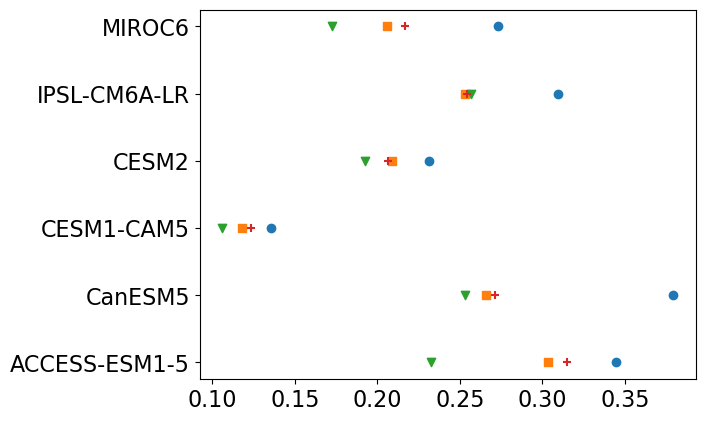

In [9]:
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:cyan','tab:purple','tab:brown']
linestyles = ['solid','dashed','dotted','dashdot']
markers = 'osv+'
for i, Thvars in enumerate((('nino3','h_eq'),('nino34','h_eq'),('nino4','h_eq'),('nino34','h_w'))):
        for model in ('ACCESS-ESM1-5','CanESM5','CESM1-CAM5','CESM2','IPSL-CM6A-LR','MIROC6'):
            T_variable, h_variable = Thvars
            indices = xr.open_dataset('indices/'+model+'_SMILE'+'_indices.nc').isel({'time':slice(120,None)}).sel({'time':slice(None,'2025')})
            T = rdl.declim_detrend_quadratic(indices[T_variable])
            h = rdl.declim_detrend_quadratic(indices[h_variable])
            plt.scatter(sigma[(model,Thvars)][0]/np.std(T),model,marker=markers[i],color=colors[i])


### Generate linear DCPP runs off all models

In [2]:
kwargs = dict(rom_type = 'linear_2D',
              T_variable = 'nino34',
              h_variable = 'h_eq',
              shape_name = 'pDCPP_qdt', #pseudo-SMILE runs, after detrending quadratically
              data_labelsel = {'time':slice(None,'2025')}, # Some of these were future at the time but I'm discarding actual future
              run_len = 122, # run length
              members=(80,40,100),  # Y, M, bootstrap. I know I will throw out some of later, but my code will be easier here if I don't yet
              detrend = rdl.declim_detrend_quadratic # how to strip climate change and seasonal cycle from data
             )



for model in ('ACCESS-ESM1-5','CanESM5','CESM1-CAM5','CESM2','IPSL-CM6A-LR','MIROC6','EC-Earth3'):
    kwargs['data_origin'] = model+'_SMILE'
    
    if model == 'CESM1-CAM5':
        kwargs['data_isel'] = {'time':slice(120,None), # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that
                     'M':np.array([False if x==32 else True for x in range(40)]) # Ensemble member 33 (index 32) has a zero in it that I do _NOT_ need
                    }
    else:
        kwargs['data_isel'] = {'time':slice(120,None)} # I'm pretty sure this is irrelevant, but I have the data to throw out 10 years so let's do that
        
    init_run = xr.open_dataset('pseudo_runs/'+model+'_SMILE_nino34_h_eq_linear_2D_pSMILE_qdt.nc').pseudo_run
    inits = init_run.rename({'M0':'M2'}).isel(time=slice(120,80*12+120,12)).rename({'time':'M0'})
    inits = (inits*xr.DataArray(np.ones(kwargs['members'][1]),dims='M1')).transpose('M0','M1','M2','v')
    
    kwargs['inits'] = inits

    t0 = time.time()
    rom = rdl.pseudo_run(**kwargs)

/Users/u6955431/Documents/CLEX Undergraduate Scholarship/CLEX_project/rom_decadal/rom_decadal_lib.py:272: UserWarning: overwriting pseudo_runs/ACCESS-ESM1-5_SMILE_nino34_h_eq_linear_2D_pDCPP_qdt.nc
  warnings.warn('overwriting '+out_filename)


In [3]:
pdcpp = xr.open_dataset('pseudo_runs/CESM1-CAm5_SMILE_nino34_h_eq_linear_2D_pDCPP_qdt.nc').pseudo_run

In [43]:
pdcpp.close()

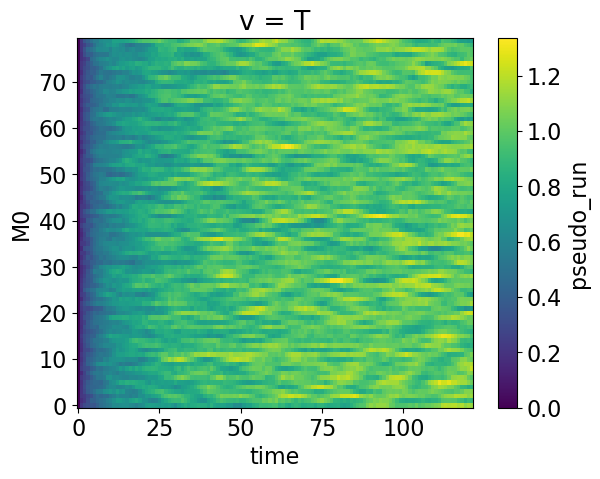

In [5]:
pdcpp.isel(M2=0,v=0).std('M1').load().plot()

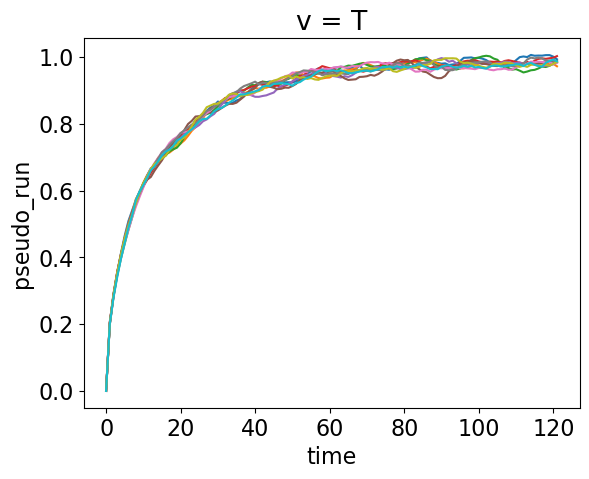

In [6]:
for i in range(10):
    pdcpp.isel(M2=i,v=0).std('M1').mean('M0').load().plot()

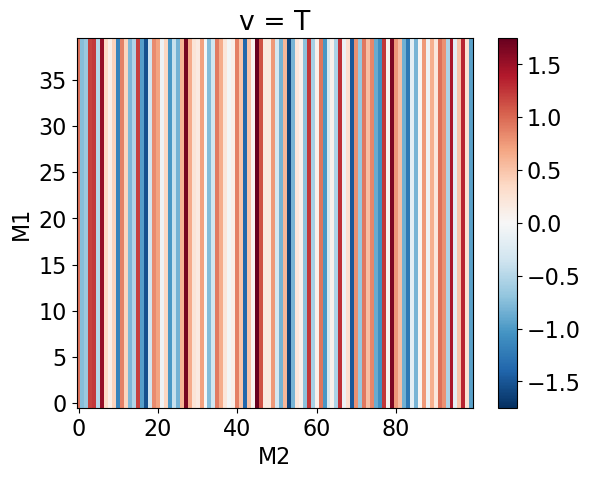

In [30]:
inits.isel(v=0,M0=0).plot()

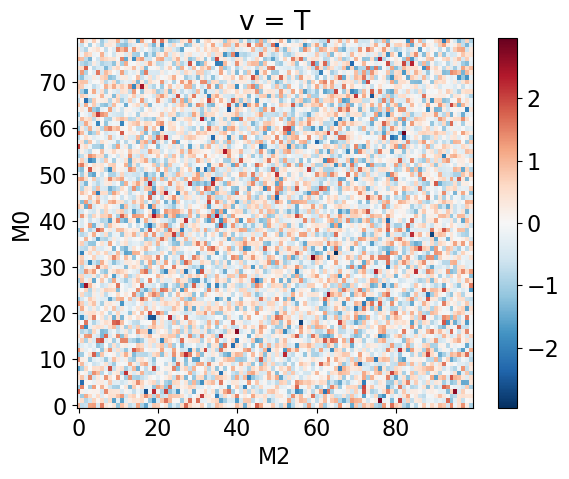

In [31]:
inits.isel(v=0,M1=0).plot()

In [26]:
inits.size*122

1952000

In [12]:
3600/80/12

3.75